In [188]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [406]:
df=pd.read_csv('/Users/haydenmonk/Downloads/HPCC/Mass_Fraction/Outputs/Ejection_Results/local_20260827_133310_ejection_results.txt', header=None)

In [407]:
df

,0,1,2
0,0.030027,0.0,Captured
1,0.030027,0.0,Captured
2,0.030027,0.0,Captured
3,0.030027,0.0,Captured
4,0.030027,0.0,Captured
...,...,...,...
3996,0.000300,2028000.0,Ejected
3997,0.000300,2037000.0,Ejected
3998,0.000300,2186000.0,Ejected
3999,0.000300,2239000.0,Ejected


In [408]:
df.columns=['mass','time','result']

In [414]:
N=[800,800,800,800,800,800]

In [415]:
masses=df.mass.unique()

In [416]:
masses

array([0.030027  , 0.0094955 , 0.00400422, 0.00168856, 0.00071206,
       0.00030027])

In [417]:
def compute_cumulative_outcome_fractions(df, masses, N):
    """
    df      : DataFrame with columns ['mass', 'time', 'particle_id', 'result']
              where result is 'Ejected' or 'Captured', and each row represents
              the time at which that particle's outcome occurred
    masses  : list/array of unique mass values, in the same order as N
    N       : list/array of total particle counts, one per mass in `masses`

    Returns
    -------
    ejection_df, capture_df : DataFrames indexed by mass, columns = sorted
                               unique time values, entries = CUMULATIVE
                               fraction of N with that result by that time
                               (i.e. fraction ejected/captured at or before
                               each time, monotonically non-decreasing
                               across each row)
    """
    if len(masses) != len(N):
        raise ValueError("masses and N must be the same length")

    mass_to_N = dict(zip(masses, N))

    times = np.sort(df["time"].unique())

    ejection_df = pd.DataFrame(index=masses, columns=times, dtype=float)
    capture_df = pd.DataFrame(index=masses, columns=times, dtype=float)

    for mass in masses:
        mass_df = df[df["mass"] == mass]
        denom = mass_to_N[mass]

        counts = (
            mass_df.groupby(["time", "result"])
            .size()
            .unstack(fill_value=0)
        )

        # reindex to the full sorted time axis, filling any missing times
        # with 0 new outcomes at that time, then cumsum across time
        ejected_counts = counts.get("Ejected", pd.Series(0, index=counts.index))
        captured_counts = counts.get("Captured", pd.Series(0, index=counts.index))

        ejected_counts = ejected_counts.reindex(times, fill_value=0)
        captured_counts = captured_counts.reindex(times, fill_value=0)

        ejection_df.loc[mass] = (ejected_counts.cumsum() / denom).values
        capture_df.loc[mass] = (captured_counts.cumsum() / denom).values

    return ejection_df, capture_df

In [418]:
ejection_df, capture_df = compute_cumulative_outcome_fractions(df, masses, N)

In [419]:
ejection_df

,0.0,7000.0,10000.0,11000.0,12000.0,13000.0,14000.0,15000.0,16000.0,17000.0,...,1943000.0,1967000.0,1970000.0,1971000.0,1992000.0,2028000.0,2037000.0,2186000.0,2239000.0,2292000.0
0.030027,0.0,0.0,0.00125,0.01,0.02375,0.0525,0.08375,0.13,0.20375,0.25125,...,0.89250,0.89250,0.89250,0.89250,0.89250,0.89250,0.89250,0.89250,0.89250,0.89250
0.009496,0.0,0.0,0.00000,0.00,0.00000,0.0000,0.00000,0.00,0.00125,0.00500,...,0.83000,0.83000,0.83000,0.83000,0.83000,0.83000,0.83000,0.83000,0.83000,0.83000
0.004004,0.0,0.0,0.00000,0.00,0.00000,0.0000,0.00000,0.00,0.00000,0.00000,...,0.81375,0.81375,0.81375,0.81375,0.81375,0.81375,0.81375,0.81375,0.81375,0.81375
0.001689,0.0,0.0,0.00000,0.00,0.00000,0.0000,0.00000,0.00,0.00000,0.00000,...,0.82625,0.82625,0.82625,0.82625,0.82625,0.82625,0.82625,0.82625,0.82625,0.82625
0.000712,0.0,0.0,0.00000,0.00,0.00000,0.0000,0.00000,0.00,0.00000,0.00000,...,0.81250,0.81250,0.81250,0.81250,0.81250,0.81250,0.81250,0.81250,0.81250,0.81250
0.000300,0.0,0.0,0.00000,0.00,0.00000,0.0000,0.00000,0.00,0.00000,0.00000,...,0.75375,0.75500,0.75625,0.75750,0.75875,0.76000,0.76125,0.76250,0.76375,0.76500


In [420]:
capture_df

,0.0,7000.0,10000.0,11000.0,12000.0,13000.0,14000.0,15000.0,16000.0,17000.0,...,1943000.0,1967000.0,1970000.0,1971000.0,1992000.0,2028000.0,2037000.0,2186000.0,2239000.0,2292000.0
0.030027,0.01750,0.01750,0.01750,0.01750,0.01750,0.01750,0.01750,0.01750,0.01750,0.01750,...,0.02250,0.02250,0.02250,0.02250,0.02250,0.02250,0.02250,0.02250,0.02250,0.02250
0.009496,0.01250,0.01250,0.01250,0.01250,0.01250,0.01250,0.01250,0.01250,0.01250,0.01250,...,0.01250,0.01250,0.01250,0.01250,0.01250,0.01250,0.01250,0.01250,0.01250,0.01250
0.004004,0.00750,0.00750,0.00750,0.00750,0.00750,0.00750,0.00750,0.00750,0.00750,0.00750,...,0.00750,0.00750,0.00750,0.00750,0.00750,0.00750,0.00750,0.00750,0.00750,0.00750
0.001689,0.00500,0.00625,0.00625,0.00625,0.00625,0.00625,0.00625,0.00625,0.00625,0.00625,...,0.00625,0.00625,0.00625,0.00625,0.00625,0.00625,0.00625,0.00625,0.00625,0.00625
0.000712,0.00250,0.00250,0.00250,0.00250,0.00250,0.00250,0.00250,0.00250,0.00250,0.00250,...,0.00625,0.00625,0.00625,0.00625,0.00625,0.00625,0.00625,0.00625,0.00625,0.00625
0.000300,0.00125,0.00125,0.00125,0.00250,0.00250,0.00250,0.00250,0.00250,0.00375,0.00375,...,0.00625,0.00625,0.00625,0.00625,0.00625,0.00625,0.00625,0.00625,0.00625,0.00625


In [421]:
def plot_fraction_by_mass(fraction_df, ylabel="Fraction"):
    masses = fraction_df.index.to_numpy()
    times = fraction_df.columns.to_numpy(dtype=float)

    ncols = 3
    nrows = int(np.ceil(len(masses) / ncols))

    fig, axes = plt.subplots(
        nrows,
        ncols,
        figsize=(5 * ncols, 4 * nrows),
        sharex=False,
        sharey=False,
    )
    axes = np.atleast_1d(axes).ravel()

    for ax, mass in zip(axes, masses):
        ax.scatter(times, fraction_df.loc[mass].to_numpy(dtype=float))

        ax.set_title(f"Mass = {mass:.3e} M_Sun")
        ax.set_xlabel("time (planet periods)")
        ax.set_ylabel(ylabel)
        ax.grid(alpha=0.3)
        ax.ticklabel_format(axis="x", style="sci", scilimits=(0, 0))

    for ax in axes[len(masses):]:
        ax.remove()

    fig.tight_layout()
    return fig, axes

In [199]:
def plot_fraction_by_mass(fraction_df, tmaxes, value=0.005, interval_ratio=1/20, ylabel="Fraction"):
    masses = fraction_df.index.to_numpy()
    times = fraction_df.columns.to_numpy(dtype=float)
    intervals = np.array(tmaxes) * interval_ratio
    vlines=time_below_increase_after_peak(fraction_df, value, intervals)
    vlines=lines
    if len(tmaxes) != len(masses):
        raise ValueError("tmaxes must have the same length as the number of masses")

    ncols = 3
    nrows = int(np.ceil(len(masses) / ncols))

    fig, axes = plt.subplots(
        nrows,
        ncols,
        figsize=(5 * ncols, 4 * nrows),
        sharex=False,
        sharey=False,
    )
    axes = np.atleast_1d(axes).ravel()

    for ax, mass, tmax, vline in zip(axes, masses, tmaxes, vlines):
        ax.scatter(
            times,
            fraction_df.loc[mass].to_numpy(dtype=float)
        )

        ax.set_xlim(0, tmax)
        ax.axvline(vline, color="red", linestyle="--")

        ax.set_title(f"Mass = {mass:.3e} M_Sun")
        ax.set_xlabel("time (planet periods)")
        ax.set_ylabel(ylabel)
        ax.grid(alpha=0.3)
        ax.ticklabel_format(axis="x", style="sci", scilimits=(0, 0))

    for ax in axes[len(masses):]:
        ax.remove()

    fig.tight_layout()
    return fig, axes

In [23]:
tmax_list=[   5_000_000,
 5_000_000,
 4_000_000,
1_000_000,
 400_000,
180_000,
100_000,
100_000,100_000]

In [24]:
def time_below_increase_after_peak(fraction_df, value, intervals):
    """
    For each mass row, find the first time after the peak slope at which
    the fraction increases by less than `value` over that mass's
    corresponding time interval.

    Parameters
    ----------
    fraction_df : pd.DataFrame
        Rows are masses and columns are times.

    value : float
        Minimum required increase in fraction over the comparison interval.

    intervals : array-like
        One comparison interval for each mass, in the same order as
        fraction_df.index.

    Returns
    -------
    pd.Series
        First timestep satisfying the criterion for each mass.
        NaN if the criterion is never satisfied.
    """

    times = fraction_df.columns.to_numpy(dtype=float)
    masses = fraction_df.index.to_numpy()

    if len(intervals) != len(masses):
        raise ValueError(
            "intervals must have the same length as the number of masses"
        )

    cadence = np.median(np.diff(times))

    result = pd.Series(index=fraction_df.index, dtype=float)

    for mass, interval in zip(masses, intervals):

        y = fraction_df.loc[mass].to_numpy(dtype=float)

        # -----------------------------------
        # Find the time of maximum slope
        # -----------------------------------
        slopes = np.diff(y) / np.diff(times)

        peak_idx = np.nanargmax(slopes)

        # slope[peak_idx] describes the interval
        # times[peak_idx] -> times[peak_idx + 1]
        peak_time_idx = peak_idx + 1


        # -----------------------------------
        # Convert this mass's interval into
        # a number of dataframe timesteps
        # -----------------------------------
        window = int(round(interval / cadence))

        if window < 1:
            raise ValueError(
                f"Interval {interval} for mass {mass} "
                f"is smaller than cadence {cadence}"
            )

        if not np.isclose(window * cadence, interval, rtol=1e-3):
            print(
                f"Warning for mass {mass}: interval={interval} "
                f"is not a clean multiple of cadence={cadence}; "
                f"using {window * cadence}"
            )


        # -----------------------------------
        # Search only after the peak slope
        # -----------------------------------
        start_idx = max(peak_time_idx + 1, window)

        found_time = np.nan

        for i in range(start_idx, len(times)):

            increase = y[i] - y[i - window]

            if increase < value:
                found_time = times[i]
                break

        result.loc[mass] = found_time

    return result

In [138]:
def last_increase_time(df):
    times = df.columns.to_numpy(dtype=float)

    result = {}

    for idx, row in df.iterrows():
        values = row.to_numpy(dtype=float)

        increases = np.diff(values) > 0

        if np.any(increases):
            last_idx = np.where(increases)[0][-1]

            # diff[last_idx] corresponds to
            # times[last_idx] -> times[last_idx + 1]
            result[idx] = times[last_idx + 1]

        else:
            result[idx] = np.nan

    return pd.Series(result, name="last_increase_time")

In [398]:
last_increase_times = last_increase_time(ejection_df)

In [227]:
last_increase_times

0.000050    4995000.0
0.000100    4993000.0
0.000300    3838000.0
0.000712     910000.0
0.001689     328000.0
0.004004     178000.0
0.009496      91000.0
0.030027      99000.0
0.100000      92000.0
Name: last_increase_time, dtype: float64

In [154]:
ejection_df.loc[ejection_df.index[0]]

0.0         0.00000
1000.0      0.00000
2000.0      0.00000
3000.0      0.00000
4000.0      0.00000
             ...   
312000.0    0.00125
325000.0    0.00125
326000.0    0.00125
327000.0    0.00125
332000.0    0.00125
Name: 5e-05, Length: 223, dtype: float64

In [159]:
axes[0]

array([<Axes: >, <Axes: >], dtype=object)

In [228]:
last_increase_times[np.isnan(last_increase_times)] = 0

In [393]:
df=pd.read_csv('/Users/haydenmonk/Downloads/HPCC/Mass_Fraction/Outputs/Ejection_Results/local_20260826_171644_ejection_results.txt', header=None)
df.columns=['mass','time','result']

In [242]:
df2=pd.read_csv('/Users/haydenmonk/Downloads/HPCC/Mass_Fraction/Outputs/Ejection_Results/local_20260823_234049_ejection_results.txt', header=None)
df2.columns=['mass','time','result']

In [244]:
df3=pd.concat([df, df2], ignore_index=True)

In [246]:
df=df3

In [219]:
df=df[['mass','time','result']]

In [394]:
masses=df.mass.unique()

In [395]:
masses

array([0.030027  , 0.0094955 , 0.00400422, 0.00168856, 0.00071206,
       0.00030027])

In [396]:
ejection_df,capture_df = compute_cumulative_outcome_fractions(df, masses, [800, 800, 800,800,800,800])

In [251]:
ejection_df

,0.0,1000.0,2000.0,3000.0,4000.0,5000.0,6000.0,7000.0,8000.0,9000.0,...,1032000.0,1043000.0,1052000.0,1054000.0,1091000.0,1101000.0,1119000.0,1126000.0,1139000.0,1140000.0
0.000300,0.0,0.0,0.00000,0.00000,0.00000,0.0000,0.00000,0.00000,0.00000,0.00000,...,0.87000,0.87125,0.87250,0.87375,0.87500,0.87625,0.87750,0.87875,0.88000,0.88125
0.000712,0.0,0.0,0.00000,0.00000,0.00000,0.0000,0.00000,0.00000,0.00000,0.00125,...,0.83500,0.83500,0.83500,0.83500,0.83500,0.83500,0.83500,0.83500,0.83500,0.83500
0.001689,0.0,0.0,0.00000,0.00000,0.00000,0.0000,0.00000,0.00250,0.00750,0.02000,...,0.82375,0.82375,0.82375,0.82375,0.82375,0.82375,0.82375,0.82375,0.82375,0.82375
0.004004,0.0,0.0,0.00125,0.00125,0.02000,0.0675,0.14375,0.21750,0.29250,0.34750,...,0.78125,0.78125,0.78125,0.78125,0.78125,0.78125,0.78125,0.78125,0.78125,0.78125
0.009496,0.0,0.0,0.00375,0.10875,0.26625,0.3975,0.48500,0.53125,0.56125,0.59250,...,0.77250,0.77250,0.77250,0.77250,0.77250,0.77250,0.77250,0.77250,0.77250,0.77250
0.030027,0.0,0.0,0.20500,0.36500,0.44125,0.4850,0.51125,0.54125,0.55250,0.56750,...,0.62500,0.62500,0.62500,0.62500,0.62500,0.62500,0.62500,0.62500,0.62500,0.62500


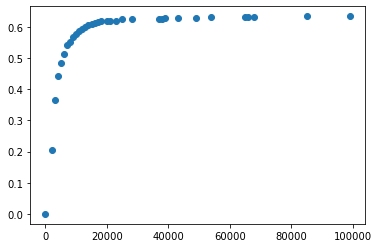

In [208]:
fig, ax=plt.subplots()
ax.scatter(ejection_df.columns, ejection_df.loc[0.030027])
#plt.xlim(0.9e6, 1.1e6)


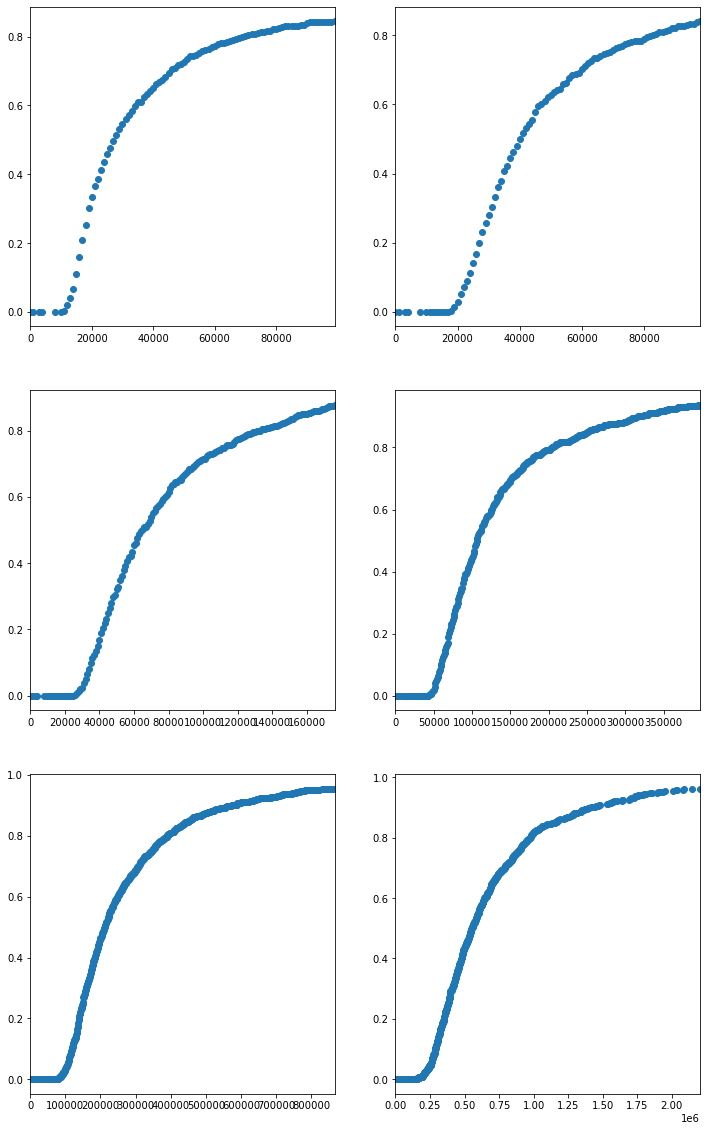

In [399]:
fig, axes = plt.subplots(
    3,
    2,
    figsize=(12, 20)
)
for mass, ax, time_below_increase_after_peak in zip(ejection_df.index, axes.ravel(), last_increase_times):
    ax.scatter(ejection_df.columns, ejection_df.loc[mass])
    ax.set_xlim(0, time_below_increase_after_peak)



In [400]:
ejection_df

,0.0,1000.0,3000.0,4000.0,8000.0,10000.0,11000.0,12000.0,13000.0,14000.0,...,1913000.0,1933000.0,1950000.0,2007000.0,2028000.0,2040000.0,2077000.0,2089000.0,2143000.0,2202000.0
0.030027,0.0,0.0,0.0,0.0,0.0,0.00000,0.00375,0.02000,0.03875,0.06500,...,0.84500,0.84500,0.84500,0.84500,0.84500,0.84500,0.84500,0.84500,0.84500,0.84500
0.009496,0.0,0.0,0.0,0.0,0.0,0.00000,0.00000,0.00000,0.00000,0.00000,...,0.84125,0.84125,0.84125,0.84125,0.84125,0.84125,0.84125,0.84125,0.84125,0.84125
0.004004,0.0,0.0,0.0,0.0,0.0,0.00000,0.00000,0.00000,0.00000,0.00000,...,0.87750,0.87750,0.87750,0.87750,0.87750,0.87750,0.87750,0.87750,0.87750,0.87750
0.001689,0.0,0.0,0.0,0.0,0.0,0.00000,0.00000,0.00000,0.00000,0.00000,...,0.93750,0.93750,0.93750,0.93750,0.93750,0.93750,0.93750,0.93750,0.93750,0.93750
0.000712,0.0,0.0,0.0,0.0,0.0,0.00125,0.00125,0.00125,0.00125,0.00125,...,0.95500,0.95500,0.95500,0.95500,0.95500,0.95500,0.95500,0.95500,0.95500,0.95500
0.000300,0.0,0.0,0.0,0.0,0.0,0.00000,0.00000,0.00000,0.00000,0.00000,...,0.95125,0.95250,0.95375,0.95500,0.95625,0.95750,0.95875,0.96000,0.96125,0.96250


In [401]:
capture_df

,0.0,1000.0,3000.0,4000.0,8000.0,10000.0,11000.0,12000.0,13000.0,14000.0,...,1913000.0,1933000.0,1950000.0,2007000.0,2028000.0,2040000.0,2077000.0,2089000.0,2143000.0,2202000.0
0.030027,0.00375,0.00375,0.00375,0.00500,0.00500,0.00500,0.00500,0.00500,0.00500,0.00500,...,0.01625,0.01625,0.01625,0.01625,0.01625,0.01625,0.01625,0.01625,0.01625,0.01625
0.009496,0.00125,0.00125,0.00125,0.00125,0.00125,0.00125,0.00125,0.00125,0.00125,0.00250,...,0.00625,0.00625,0.00625,0.00625,0.00625,0.00625,0.00625,0.00625,0.00625,0.00625
0.004004,0.00125,0.00250,0.00375,0.00375,0.00375,0.00375,0.00375,0.00375,0.00375,0.00375,...,0.00375,0.00375,0.00375,0.00375,0.00375,0.00375,0.00375,0.00375,0.00375,0.00375
0.001689,0.00000,0.00125,0.00125,0.00125,0.00125,0.00125,0.00125,0.00125,0.00125,0.00250,...,0.00250,0.00250,0.00250,0.00250,0.00250,0.00250,0.00250,0.00250,0.00250,0.00250
0.000712,0.00000,0.00000,0.00000,0.00000,0.00125,0.00125,0.00125,0.00125,0.00125,0.00125,...,0.00250,0.00250,0.00250,0.00250,0.00250,0.00250,0.00250,0.00250,0.00250,0.00250
0.000300,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,...,0.00625,0.00625,0.00625,0.00625,0.00625,0.00625,0.00625,0.00625,0.00625,0.00625


In [405]:
ejection_df

,0.0,1000.0,3000.0,4000.0,8000.0,10000.0,11000.0,12000.0,13000.0,14000.0,...,1913000.0,1933000.0,1950000.0,2007000.0,2028000.0,2040000.0,2077000.0,2089000.0,2143000.0,2202000.0
0.030027,0.0,0.0,0.0,0.0,0.0,0.00000,0.00375,0.02000,0.03875,0.06500,...,0.84500,0.84500,0.84500,0.84500,0.84500,0.84500,0.84500,0.84500,0.84500,0.84500
0.009496,0.0,0.0,0.0,0.0,0.0,0.00000,0.00000,0.00000,0.00000,0.00000,...,0.84125,0.84125,0.84125,0.84125,0.84125,0.84125,0.84125,0.84125,0.84125,0.84125
0.004004,0.0,0.0,0.0,0.0,0.0,0.00000,0.00000,0.00000,0.00000,0.00000,...,0.87750,0.87750,0.87750,0.87750,0.87750,0.87750,0.87750,0.87750,0.87750,0.87750
0.001689,0.0,0.0,0.0,0.0,0.0,0.00000,0.00000,0.00000,0.00000,0.00000,...,0.93750,0.93750,0.93750,0.93750,0.93750,0.93750,0.93750,0.93750,0.93750,0.93750
0.000712,0.0,0.0,0.0,0.0,0.0,0.00125,0.00125,0.00125,0.00125,0.00125,...,0.95500,0.95500,0.95500,0.95500,0.95500,0.95500,0.95500,0.95500,0.95500,0.95500
0.000300,0.0,0.0,0.0,0.0,0.0,0.00000,0.00000,0.00000,0.00000,0.00000,...,0.95125,0.95250,0.95375,0.95500,0.95625,0.95750,0.95875,0.96000,0.96125,0.96250


KeyError: 'mass'

In [288]:
rng = np.random.default_rng(10)


In [267]:
ejection_df.columns.astype(int)

Index([      0,    1000,    2000,    3000,    4000,    5000,    6000,    7000,
          8000,    9000,
       ...
       1032000, 1043000, 1052000, 1054000, 1091000, 1101000, 1119000, 1126000,
       1139000, 1140000],
      dtype='int64', length=545)

Mass: 0.00030027, Time: 1140000.0
Mass: 0.00071206, Time: 332000.0
Mass: 0.00168856, Time: 102000.0
Mass: 0.00400422, Time: 53000.0
Mass: 0.0094955, Time: 28000.0
Mass: 0.030027, Time: 16000.0


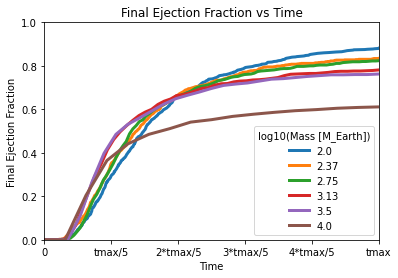

In [389]:
for mass, time_below_increase_after_peak in zip(ejection_df.index, last_increase_times.iloc):
    print(f"Mass: {mass}, Time: {time_below_increase_after_peak}")
    plt.plot(ejection_df.columns.astype(int)/time_below_increase_after_peak, ejection_df.loc[mass], label=round(np.log10(mass*333030),2), linewidth=3)
# for mass, time_below_increase_after_peak in zip(ejection_df.index[-2:], last_increase_times.iloc[-2:]):
#     print(f"Mass: {mass}, Time: {time_below_increase_after_peak}")
#     plt.plot(ejection_df.columns.astype(int)/(time_below_increase_after_peak), ejection_df.loc[mass], label=round(np.log10(mass*333030),2), linewidth=5)
#     # ax.set_xlim(0, time_below_increase_after_peak)


plt.xlim(0,1)
plt.ylim(0,1)
plt.legend(title='log10(Mass [M_Earth])', loc='lower right')
ticks=np.linspace(0,1,6)
tick_labels = np.array(['0','tmax/5','2*tmax/5','3*tmax/5','4*tmax/5','tmax'])



plt.xticks(
    ticks,
    tick_labels
)
plt.ylabel('Final Ejection Fraction')
plt.xlabel('Time')
plt.title('Final Ejection Fraction vs Time')
plt.savefig('/Users/haydenmonk/Downloads/HPCC/Mass_Fraction/Outputs/Visualizations/final_ejection_fraction_vs_time.png', dpi=300,    bbox_inches="tight",facecolor="white")

In [318]:
last_increase_times.index

Index([0.00030027, 0.00071206, 0.00168856, 0.00400422, 0.0094955, 0.030027], dtype='float64')

In [321]:
last_increase_times[.030027]=last_increase_times[.030027]-12000

In [323]:
f_final_list=[]
for mass, time_below_increase_after_peak in zip(ejection_df.index, last_increase_times.iloc):
    f_final_list.append(ejection_df.loc[mass].loc[time_below_increase_after_peak])

In [324]:
f_final_list

[0.88125, 0.835, 0.82375, 0.78125, 0.7625, 0.61125]

In [374]:
last_increase_times['final_mass_fraciton']=f_final_list

In [375]:
last_increase_times

0.0003                                                         1140000.0
0.000712                                                        332000.0
0.001689                                                        102000.0
0.004004                                                         53000.0
0.009496                                                         28000.0
0.030027                                                         16000.0
final_mass_fraciton    [0.88125, 0.835, 0.82375, 0.78125, 0.7625, 0.6...
Name: last_increase_time, dtype: object

In [376]:
output_df = last_increase_times.to_frame(name="t_stop")

In [377]:
output_df

,t_stop
0.0003,1140000.0
0.000712,332000.0
0.001689,102000.0
0.004004,53000.0
0.009496,28000.0
0.030027,16000.0
final_mass_fraciton,"[0.88125, 0.835, 0.82375, 0.78125, 0.7625, 0.6..."


In [ ]:
#last_increase_times = last_increase_times.drop("final_mass_fraction")
output_df = last_increase_times.to_frame(name="t_max")
output_df["final_mass_fraction"] = f_final_list
output_df.index.name = "mass"

In [381]:
output_df

,t_stop,final_mass_fraction
mass,,
0.0003,1140000.0,0.88125
0.000712,332000.0,0.83500
0.001689,102000.0,0.82375
0.004004,53000.0,0.78125
0.009496,28000.0,0.76250
0.030027,16000.0,0.61125


In [385]:
def save_dataframe_as_image(df, filename="dataframe_table.png"):
    fig_width = max(6, 1.2 * len(df.columns))
    fig_height = max(2, 0.45 * (len(df) + 1))

    fig, ax = plt.subplots(figsize=(fig_width, fig_height))
    ax.axis("off")

    table = ax.table(
        cellText=df.values,
        colLabels=df.columns,
        rowLabels=df.index,
        cellLoc="center",
        loc="center"
    )

    table.auto_set_font_size(False)
    table.set_fontsize(10)
    table.scale(1, 1.5)

    plt.savefig(
    filename,
    dpi=300,
    bbox_inches="tight",
    pad_inches=0.05,
    facecolor="white",
    transparent=False
)
    plt.close(fig)

In [386]:
save_dataframe_as_image(output_df, filename='/Users/haydenmonk/Downloads/HPCC/Mass_Fraction/Outputs/Visualizations/final_proportion_table.png')

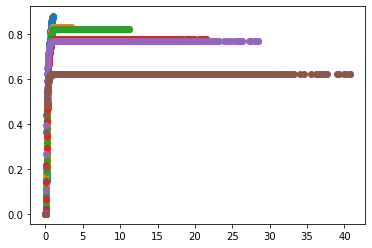

In [272]:
for mass, tscale in zip(ejection_df.index, last_increase_times):

    scaled_time = ejection_df.columns.astype(float) / tscale

    plt.scatter(
        scaled_time,
        ejection_df.loc[mass],
        label=str(mass),
    )

In [255]:
def chaotic_zone(mass_ratio):
    return 1.3 * mass_ratio**(2/7)
def hill_radius(m_planet, a_planet=1.0, m_star=1.0):
    return a_planet * (m_planet / (3 * m_star)) ** (1 / 3)

In [260]:

print(hill_radius(masses)*2*np.sqrt(3)/chaotic_zone(masses))

[1.2556521  1.30835829 1.36327612 1.42049935 1.48012426 1.56353433]


Text(0.5, 1.0, 'Chaotic Zone Proportion vs Final Mass Fraction')

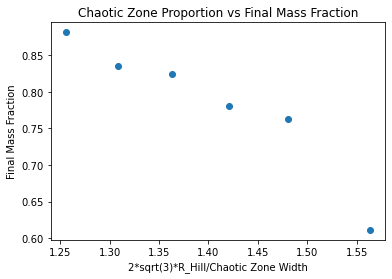

In [330]:
plt.scatter(hill_radius(masses)*2*np.sqrt(3)/chaotic_zone(masses),f_final_list)
plt.xlabel('2*sqrt(3)*R_Hill/Chaotic Zone Width')
plt.ylabel('Final Mass Fraction')
plt.title('Chaotic Zone Proportion vs Final Mass Fraction')

[0.16083758 0.21448112 0.28601515 0.38140775 0.50861537 0.7465419 ]


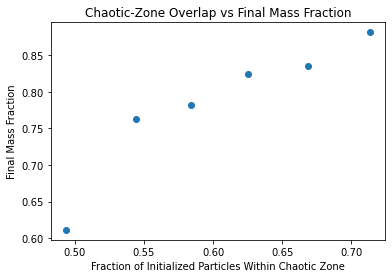

In [ ]:
R_H = hill_radius(masses)
cz = chaotic_zone(masses)
print(R_H)

inner = R_H
outer = 2 * np.sqrt(3) * R_H

chaotic_fraction = np.clip(
    (np.minimum(cz, outer) - inner) / (outer - inner),
    0,
    1
)

plt.scatter(chaotic_fraction, f_final_list)

plt.xlabel("Fraction of Initialized Particles Within Chaotic Zone")
plt.ylabel("Final Mass Fraction")
plt.title("Chaotic-Zone Overlap vs Final Mass Fraction")
plt.savefig('/Users/haydenmonk/Downloads/HPCC/Mass_Fraction/Outputs/Visualizations/chaotic_zone_overlap_vs_final_mass_fraction.png', dpi=300,    bbox_inches="tight",facecolor="white")

In [331]:
position_df=pd.read_csv('/Users/haydenmonk/Downloads/HPCC/Mass_Fraction/Outputs/Ejection_Results/remaining_particles_local_20260824_225601_0.csv')

In [338]:
position_file_list=[
    '/Users/haydenmonk/Downloads/HPCC/Mass_Fraction/Outputs/Ejection_Results/remaining_particles_local_20260824_225601_1.csv',
    '/Users/haydenmonk/Downloads/HPCC/Mass_Fraction/Outputs/Ejection_Results/remaining_particles_local_20260824_225601_2.csv',
    '/Users/haydenmonk/Downloads/HPCC/Mass_Fraction/Outputs/Ejection_Results/remaining_particles_local_20260824_225601_3.csv',
    '/Users/haydenmonk/Downloads/HPCC/Mass_Fraction/Outputs/Ejection_Results/remaining_particles_local_20260824_225601_4.csv',
    '/Users/haydenmonk/Downloads/HPCC/Mass_Fraction/Outputs/Ejection_Results/remaining_particles_local_20260824_225601_5.csv'
]

In [339]:
for mass in position_file_list:
    temp_df=pd.read_csv(mass)
    position_df=pd.concat([position_df,temp_df],ignore_index=True)

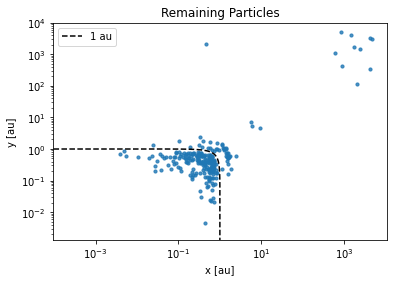

In [ ]:

plt.scatter(position_df.x,position_df.y, alpha=0.8, s=10)

plt.yscale('log')
plt.xscale('log')
plt.title('Remaining Particles')
plt.xlabel('x [au]')
plt.ylabel('y [au]')
thetas=np.linspace(0,2*np.pi, 100)
plt.plot(np.cos(thetas),np.sin(thetas), color='black', linestyle='--', label='1 au')
plt.legend()
#plt.savefig('/Users/haydenmonk/Downloads/HPCC/Mass_Fraction/Outputs/Visualizations/remaining_particles.png', dpi=300)

In [355]:
f_final_list

[0.88125, 0.835, 0.82375, 0.78125, 0.7625, 0.61125]

In [232]:
fitting_ejection_df=ejection_df.drop([5e-05,     0.0001])

In [234]:
fitting_ejection_df=ejection_df.drop([5e-05,     0.0001,0.030027,        0.1 ])

In [235]:
fitting_ejection_df

,0.0,1000.0,2000.0,3000.0,4000.0,5000.0,6000.0,7000.0,8000.0,9000.0,...,4972000.0,4976000.0,4977000.0,4981000.0,4982000.0,4984000.0,4991000.0,4993000.0,4994000.0,4995000.0
0.000300,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.595556,0.595556,0.595556,0.595556,0.595556,0.595556,0.595556,0.595556,0.595556,0.595556
0.000712,0.0,0.000000,0.000222,0.000222,0.000444,0.000667,0.000667,0.000667,0.000667,0.000667,...,0.575556,0.575556,0.575556,0.575556,0.575556,0.575556,0.575556,0.575556,0.575556,0.575556
0.001689,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.001111,0.002667,0.008667,0.020889,...,0.584667,0.584667,0.584667,0.584667,0.584667,0.584667,0.584667,0.584667,0.584667,0.584667
0.004004,0.0,0.000222,0.000222,0.000667,0.018222,0.058222,0.111111,0.160889,0.214000,0.253778,...,0.570667,0.570667,0.570667,0.570667,0.570667,0.570667,0.570667,0.570667,0.570667,0.570667
0.009496,0.0,0.000222,0.006667,0.093778,0.217111,0.311333,0.379556,0.421778,0.448889,0.470222,...,0.611333,0.611333,0.611333,0.611333,0.611333,0.611333,0.611333,0.611333,0.611333,0.611333


In [230]:
ejection_df.drop?

Signature:
ejection_df.drop(
    labels: 'IndexLabel | None' = None,
    *,
    axis: 'Axis' = 0,
    index: 'IndexLabel | None' = None,
    columns: 'IndexLabel | None' = None,
    level: 'Level | None' = None,
    inplace: 'bool' = False,
    errors: 'IgnoreRaise' = 'raise',
) -> 'DataFrame | None'
Docstring:
Drop specified labels from rows or columns.

Remove rows or columns by specifying label names and corresponding
axis, or by directly specifying index or column names. When using a
multi-index, labels on different levels can be removed by specifying
the level. See the :ref:`user guide <advanced.shown_levels>`
for more information about the now unused levels.

Parameters
----------
labels : single label or list-like
    Index or column labels to drop. A tuple will be used as a single
    label and not treated as a list-like.
axis : {0 or 'index', 1 or 'columns'}, default 0
    Whether to drop labels from the index (0 or 'index') or
    columns (1 or 'columns').
index : single labe

In [141]:
plot_fraction_by_mass(ejection_df, last_increase_times

SyntaxError: incomplete input (2752845550.py, line 1)

In [83]:
ejection_df.index

Index([     5e-05,     0.0001, 0.00030027, 0.00071206, 0.00168856, 0.00400422,
        0.0094955,   0.030027,        0.1],
      dtype='float64')

(0.0, 40000.0)

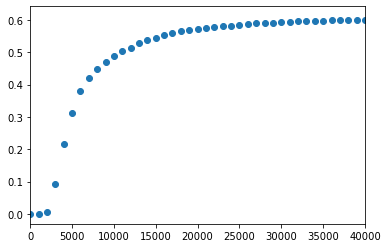

In [86]:
plt.scatter(ejection_df.columns.to_numpy(dtype=float), ejection_df.loc[0.0094955].to_numpy(dtype=float))
plt.xlim(0, 40_000)


In [26]:
ejection_df

,0.0,1000.0,2000.0,3000.0,4000.0,5000.0,6000.0,7000.0,8000.0,9000.0,...,4972000.0,4976000.0,4977000.0,4981000.0,4982000.0,4984000.0,4991000.0,4993000.0,4994000.0,4995000.0
0.000050,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.126667,0.126889,0.127111,0.127333,0.127556,0.127556,0.127556,0.127556,0.127778,0.128000
0.000100,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.488444,0.488444,0.488667,0.488667,0.488889,0.489111,0.489333,0.489556,0.489556,0.489556
0.000300,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.595556,0.595556,0.595556,0.595556,0.595556,0.595556,0.595556,0.595556,0.595556,0.595556
0.000712,0.0,0.000000,0.000222,0.000222,0.000444,0.000667,0.000667,0.000667,0.000667,0.000667,...,0.575556,0.575556,0.575556,0.575556,0.575556,0.575556,0.575556,0.575556,0.575556,0.575556
0.001689,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.001111,0.002667,0.008667,0.020889,...,0.584667,0.584667,0.584667,0.584667,0.584667,0.584667,0.584667,0.584667,0.584667,0.584667
0.004004,0.0,0.000222,0.000222,0.000667,0.018222,0.058222,0.111111,0.160889,0.214000,0.253778,...,0.570667,0.570667,0.570667,0.570667,0.570667,0.570667,0.570667,0.570667,0.570667,0.570667
0.009496,0.0,0.000222,0.006667,0.093778,0.217111,0.311333,0.379556,0.421778,0.448889,0.470222,...,0.611333,0.611333,0.611333,0.611333,0.611333,0.611333,0.611333,0.611333,0.611333,0.611333
0.030027,0.0,0.009333,0.180444,0.320667,0.378889,0.418889,0.443111,0.460889,0.476000,0.485778,...,0.525111,0.525111,0.525111,0.525111,0.525111,0.525111,0.525111,0.525111,0.525111,0.525111
0.100000,0.0,0.089111,0.358222,0.460222,0.509333,0.536000,0.551778,0.561778,0.569333,0.578222,...,0.600889,0.600889,0.600889,0.600889,0.600889,0.600889,0.600889,0.600889,0.600889,0.600889


In [30]:
slope_df=ejection_df-ejection_df.shift(periods=1, axis=1)

In [49]:
t_peak=slope_df.idxmax(axis=1)

In [52]:
np.array(t_peak)

array([4.228e+06, 1.691e+06, 2.170e+05, 4.400e+04, 1.300e+04, 8.000e+03,
       4.000e+03, 2.000e+03, 2.000e+03])

In [54]:
np.round?

Signature:       np.round(a, decimals=0, out=None)
Call signature:  np.round(*args, **kwargs)
Type:            _ArrayFunctionDispatcher
String form:     <function round at 0x1064f3b00>
File:            ~/mambaforge/envs/comets/lib/python3.11/site-packages/numpy/core/fromnumeric.py
Docstring:      
Evenly round to the given number of decimals.

Parameters
----------
a : array_like
    Input data.
decimals : int, optional
    Number of decimal places to round to (default: 0).  If
    decimals is negative, it specifies the number of positions to
    the left of the decimal point.
out : ndarray, optional
    Alternative output array in which to place the result. It must have
    the same shape as the expected output, but the type of the output
    values will be cast if necessary. See :ref:`ufuncs-output-type` for more
    details.

Returns
-------
rounded_array : ndarray
    An array of the same type as `a`, containing the rounded values.
    Unless `out` was specified, a new array is cre

In [64]:
ceileing_cadence=1000*np.ceil(np.array(t_peak)/10000)

In [73]:
lines=time_below_increase_after_peak(ejection_df, value=0.01, intervals=2*np.array(t_peak))

In [66]:
lines

0.000050         NaN
0.000100         NaN
0.000300    566000.0
0.000712    126000.0
0.001689     43000.0
0.004004     19000.0
0.009496     14000.0
0.030027      9000.0
0.100000      8000.0
dtype: float64

In [31]:
slope_df

,0.0,1000.0,2000.0,3000.0,4000.0,5000.0,6000.0,7000.0,8000.0,9000.0,...,4972000.0,4976000.0,4977000.0,4981000.0,4982000.0,4984000.0,4991000.0,4993000.0,4994000.0,4995000.0
0.000050,NaN,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000222,0.000222,0.000222,0.000222,0.000000,0.000000,0.000000,0.000222,0.000222
0.000100,NaN,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000222,0.000000,0.000222,0.000000,0.000222,0.000222,0.000222,0.000222,0.000000,0.000000
0.000300,NaN,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
0.000712,NaN,0.000000,0.000222,0.000000,0.000222,0.000222,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
0.001689,NaN,0.000000,0.000000,0.000000,0.000000,0.000000,0.001111,0.001556,0.006000,0.012222,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
0.004004,NaN,0.000222,0.000000,0.000444,0.017556,0.040000,0.052889,0.049778,0.053111,0.039778,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
0.009496,NaN,0.000222,0.006444,0.087111,0.123333,0.094222,0.068222,0.042222,0.027111,0.021333,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
0.030027,NaN,0.009333,0.171111,0.140222,0.058222,0.040000,0.024222,0.017778,0.015111,0.009778,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
0.100000,NaN,0.089111,0.269111,0.102000,0.049111,0.026667,0.015778,0.010000,0.007556,0.008889,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000


(0.0, 400000.0)

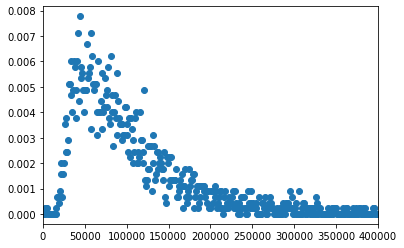

In [42]:
plt.scatter(slope_df.columns, slope_df.loc[0.00071206])
plt.xlim(0, 400_000)

In [34]:
slope_df.loc[0.1]

0.0               NaN
1000.0       0.089111
2000.0       0.269111
3000.0       0.102000
4000.0       0.049111
               ...   
4984000.0    0.000000
4991000.0    0.000000
4993000.0    0.000000
4994000.0    0.000000
4995000.0    0.000000
Name: 0.1, Length: 2804, dtype: float64

In [38]:
slope_df.index

Index([     5e-05,     0.0001, 0.00030027, 0.00071206, 0.00168856, 0.00400422,
        0.0094955,   0.030027,        0.1],
      dtype='float64')